# Hungarian Dataset Simulation and Optimization

# ONLY ONE WEEK DATA

In [1]:
from utils import data_path, tech_colors, cost_params, week_numbers
from visualizations import plot_generator_t

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pypsa

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Create analyzed dates
- **week 15**: April 8 - April 14

In [2]:
dates = pd.date_range(start=pd.to_datetime('2000-01-01')+pd.Timedelta(weeks=14), 
                      end=pd.to_datetime('2000-01-01')+pd.Timedelta(weeks=14)+pd.Timedelta(days=6, hours=23),
                      freq='h').to_list()

# Import Data

In [3]:
potentials_generator = pd.read_excel(data_path, sheet_name='potentials_generator', index_col=0, na_values='None')
potentials_storage = pd.read_excel(data_path, sheet_name='potentials_storage', index_col=0, na_values='None')
costs_generator = pd.read_excel(data_path, sheet_name='costs_generator', index_col=0, na_values='None').to_dict()
costs_storage = pd.read_excel(data_path, sheet_name='costs_storage', index_col=0, na_values='None').to_dict()
profile_wind = pd.read_excel(data_path, sheet_name='profile_wind', names=list(week_numbers.keys()), header=None, index_col=0)['week_15']
profile_PV = pd.read_excel(data_path, sheet_name='profile_PV', names=list(week_numbers.keys()), header=None, index_col=0)['week_15']
demand = pd.read_excel(data_path, sheet_name='demand').values[:7].ravel()

# PyPSA - Network & Optimizations

- [Generator parameters](https://docs.pypsa.org/latest/api/components/types/generators/#pypsa.components.Generators.add) 
- [Storage Unit paramaters](https://docs.pypsa.org/latest/api/components/types/storage-units/#pypsa.components.StorageUnits.add)
    <!--     - `p_nom` / `p_nom_extendable`: nominális teljesítmény (korlátoztható/bővíthető)
    - `p_nom_min` / `p_nom_max` / `p_nom_set`
    - `p_min_pu` / `p_max_pu`: min input / max output for each snapshot
    --->




- [HiGHS](https://en.wikipedia.org/wiki/HiGHS_optimization_solver)

In [4]:
# Create a subset
subset = ['Solar', 'Nuclear', 'Waste', 'Fossil Hard coal']
pg, cg = pd.DataFrame([]), {}
for s in subset:
    pg[s] = potentials_generator[s]
    cg[s] = costs_generator[s]

potentials_generator, costs_generator = pg, cg
### Modifciations:
potentials_generator.loc["p_nom_max", 'Waste']=1800
potentials_generator.loc["p_nom_min", 'Waste']=1000
potentials_generator.loc["p_nom", 'Waste']=1000

potentials_generator.loc["p_nom_max", 'Nuclear']=2500
potentials_generator.loc["p_nom_min", 'Nuclear']=1900

potentials_generator.loc["p_nom_min", 'Solar']=500

potentials_generator.loc["p_nom_max", 'Fossil Hard coal']=20000
potentials_generator.loc["p_nom", 'Fossil Hard coal']=0
costs_generator['Fossil Hard coal']['capital']+=20000
costs_generator['Fossil Hard coal']['operation']+=10000

potentials_generator


,Solar,Nuclear,Waste,Fossil Hard coal
p_nom,4000.0,2000.000,1000.00,0.00
p_nom_max,6000.0,2500.000,1800.00,20000.00
p_nom_min,500.0,1900.000,1000.00,0.00
up,NaN,0.000,0.00,0.00
down,NaN,0.000,0.00,0.00
ramp_up,1.0,0.005,0.01,0.01
ramp_down,1.0,0.005,0.01,0.01


In [5]:
# Building the network
network = pypsa.Network(name='Network')

# Time stamps
snapshots = np.array(dates)
network.set_snapshots(list(snapshots))

# Base electrical network
network.add(class_name="Bus", 
            name="country_0",
            carrier='AC'
           )

# Set a carrier for the network
network.add(class_name='Carrier',
            name='AC'
           )

# Add demand to the network
network.add(class_name="Load", 
            name="Residential demand",  
            bus="country_0", 
            p_set=demand
           )   

# Add generators to the network
for technology in potentials_generator.keys(): 
    p_max_pu=1
    p_min_pu=0
    p_nom_extendable=True
    committable=False
    ramp_limit_start_up=1
    ramp_limit_shut_down=1
    min_up_time=4
    min_down_time=4

    if technology in ['Solar']:
        p_max_pu=np.tile(profile_PV.values, len(dates)//24)  # type: ignore (VSCode warning)
    elif technology in ['Nuclear']:
        committable=True
        #p_min_pu=0.7
    elif technology in ['Fossil Hard coal']:
        committable=True
        ramp_limit_start_up=1
        ramp_limit_shut_down=1
        min_up_time=4
        min_down_time=2

    # adding generators
    network.add(class_name="Generator", 
                name=str(technology),
                bus="country_0",
                #p_nom=potentials_generator.loc['p_nom', str(technology)],
                p_nom_extendable=p_nom_extendable, # optimisable generator capacity
                p_nom_max=potentials_generator.loc['p_nom_max', str(technology)], # maximum limit
                p_nom_min=potentials_generator.loc['p_nom_min', str(technology)], # minimum limit
                
                capital_cost=costs_generator[str(technology)]['capital'], # generator installation cost
                marginal_cost=sum([costs_generator[str(technology)][key] for key in cost_params[1:]]), # operating cost
                p_max_pu=p_max_pu, # maximum power per-unit // production profiles
                p_min_pu=p_min_pu, # minimum power per-unit // production profiles
                
                ramp_limit_up=potentials_generator.loc['ramp_up', str(technology)],   # maximum increase per hour
                ramp_limit_down=potentials_generator.loc['ramp_down', str(technology)], # maximum decrease per hour

                committable=committable,
                ramp_limit_start_up=ramp_limit_start_up,
                ramp_limit_shut_down=ramp_limit_shut_down,
                min_up_time=min_up_time,
                min_down_time=min_down_time,

               )

# Storage units creation
for technology in potentials_storage.keys():
    network.add(class_name="StorageUnit", 
                name=str(technology),
                bus="country_0",
                p_nom_extendable=True, # optimisable storage capacity
                p_nom_max=potentials_storage.loc['p_nom_max', str(technology)], # maximum limit
                capital_cost=costs_storage[str(technology)]['capital'], # installation cost
                marginal_cost=sum([costs_storage[str(technology)][key] for key in cost_params[1:]]), # operating cost
               )    
    
# Optimization
network.sanitize()
result = network.optimize(solver_name='highs', 
                          solver_options={'presolve':'on', 
                                          'threads':'all',
                                          'log_to_console': True,
                                          'tolerance': 0.01,
                                          'mip_rel_gap': 0.01, # For integer problems
                                          'primal_feasibility_tolerance': 1e-5,
                                          'dual_feasibility_tolerance': 1e-5,
                                          #'max_iterations': 1000,
                                          'time_limit': 500  # seconds
                                         }
                         )

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - presolve: on
 - threads: all
 - log_to_console: True
 - tolerance: 0.01
 - mip_rel_gap: 0.01
 - primal_feasibility_tolerance: 1e-05
 - dual_feasibility_tolerance: 1e-05
 - time_limit: 500
INFO:linopy.io: Writing time: 1.4s


ERROR:   getOptionIndex: Option "tolerance" is unknown
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP linopy-problem-mynk_nie has 8906 rows; 2694 cols; 22397 nonzeros; 1008 integer variables (1008 binary)
Coefficient ranges:
  Matrix  [8e-04, 2e+04]
  Cost    [1e-01, 3e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+04]
Presolving model
5256 rows, 2113 cols, 16884 nonzeros 0s
4910 rows, 2109 cols, 16180 nonzeros 0s
Presolve reductions: rows 4910(-3996); columns 2109(-585); nonzeros 16180(-6217) 

Solving MIP model with:
   4910 rows
   2109 cols (986 binary, 0 integer, 0 implied int., 1123 continuous, 0 domain fixed)
   16180 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2694 primals, 9920 duals
Objective: 5.95e+07
Solver: highs
Runtime: 14.30s
MIP gap: 8.09e-03
Dual bound: 5.91e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-status-p-fixed-upper, Generator-start_up-p-fixed-upper, Generator-shut_down-p-fixed-upper, Generator-ext-p-lower, Generator-ext-p-upper, Generator-com-ext-p-lower, Generator-com-ext-p-upper-bigM, Generator-com-ext-p-upper-cap, Generator-com-ext-p-lower-nonneg, Generator-com-transition-start-up, Generator-com-transition-shut-down, Generator-com-up-time, Generator-com-down-time, Generator-com-status-min_up_time_must_stay_up, Generator-p-ramp_limit_up, Generator-p-ramp_limit_down, Generator-p-ramp_limit_up-run-bigM, Generator-p-ramp_limit_up-start-bigM, Generator-p-ramp_limit_down-run-bigM, Generator-p-ramp_limit_down-shut-bigM, StorageUnit-ext-p_disp

         1       0         0 100.00%   59053794.19813  59535490.54359     0.81%     2650    258     47     35699    14.3s

Solving report
  Model             linopy-problem-mynk_nie
  Status            Optimal
  Primal bound      59535490.5436
  Dual bound        59053794.1981
  Gap               0.809% (tolerance: 1%)
  P-D integral      0.454945064869
  Solution status   feasible
                    59535490.5436 (objective)
                    0 (bound viol.)
                    0 (int. viol.)
                    0 (row viol.)
  Timing            14.30
  Max sub-MIP depth 4
  Nodes             1
  Repair LPs        0
  LP iterations     35699
                    4176 (strong br.)
                    10989 (separation)
                    16102 (heuristics)


In [6]:
network.generators.p_nom_opt

name
Solar               1862.646047
Nuclear             2128.627706
Waste               1800.000000
Fossil Hard coal      -0.000000
Name: p_nom_opt, dtype: float64

In [7]:
network.generators_t.p['Fossil Hard coal'].values.max()

np.float64(-0.0)

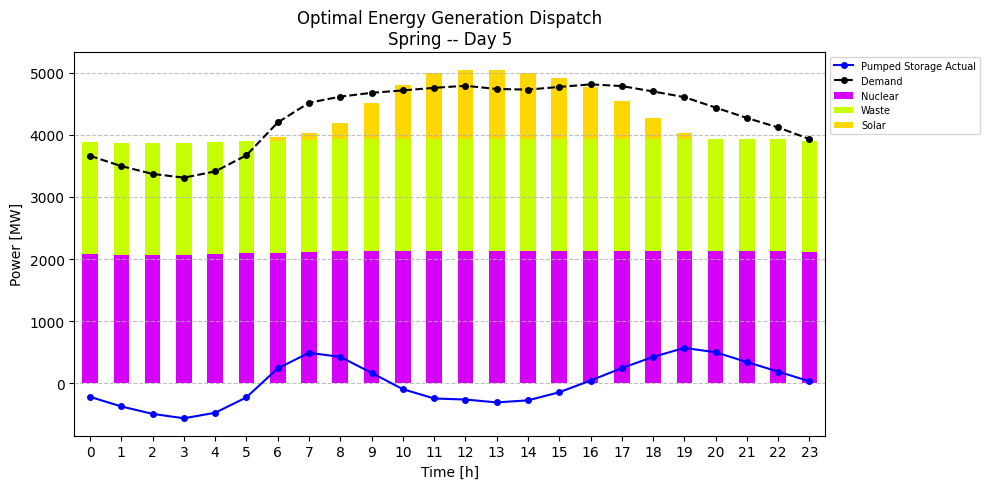

In [8]:
if result[0] == 'ok':
    plot_generator_t(network, [dates], season='Spring', day=5, colors=tech_colors, demand=demand)